# TeNNet-SAC Demonstration Notebook

This notebook demonstrates how to use the TeNNet-SAC framework to:

- Predict **σ-profiles** and molecular geometry from SMILES strings  
- Predict **activity coefficients** for both binary and multicomponent mixtures  
  - You can choose between the **Base model** (trained on COSMO-SAC data) and the **Fine-tuned model** (refined with experimental data)

## Import

In [1]:
# === Standard Library ===
import os
import warnings

# === Computing & Visualization ===
import torch
import pandas as pd
import numpy as np

# === Warning Suppression ===
from tqdm import TqdmWarning
warnings.simplefilter("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", message="TypedStorage is deprecated")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Some weights of RobertaModel were not initialized")
from transformers.utils import logging
logging.set_verbosity_error()

# === Model Architectures ===
from models.Emb2Profile import SigmaProfileGenerator
from models.Emb2Geometry import GeometryGenerator
from models.Prf2Gamma import Prf_to_Seg_Model

# === Model Loading ===
from utils.model_io import load_model, load_all_Gamma_models

# === Embedding Extraction ===

from utils.embedding import ChemBERTaEmbedder, SMITEDEmbedder

# === Computation ===
from utils.property import get_sigma_profile, calc_ln_gamma, calc_ln_gamma_binary

# === Poltting ===
from utils.plotting import plot_sigma_prf, plot_sigma_prf_pair, plot_binary_lng


## Load models and define functions

In [2]:
# === Embedding models ===
cb_emb = ChemBERTaEmbedder()
st_emb = SMITEDEmbedder()

# === Load checkpoints ===
ckpt_path = "./ckpt_files"
prf_model = load_model(SigmaProfileGenerator(), os.path.join(ckpt_path, "prf.ckpt"))
geometry_model = load_model(GeometryGenerator(), os.path.join(ckpt_path, "geo.ckpt"))
Gamma_base_model = load_model(Prf_to_Seg_Model(), os.path.join(ckpt_path, "base.ckpt"))

Gamma_finetuned_models = load_all_Gamma_models(Prf_to_Seg_Model, os.path.join(ckpt_path, "fine-tuned"))

# === Define functions ===
def sigma_profile_wrapper(smiles):
    return get_sigma_profile(smiles, prf_model, geometry_model, cb_emb, st_emb)

def single_model_predictor(sigma, temperature):
    return Gamma_base_model(sigma, torch.tensor([temperature]))[1]


def select_gamma_predictor(model_type: str):
    if model_type == "base":
        return [Gamma_base_model]
    elif model_type == "tuned":
        return Gamma_finetuned_models
    else:
        raise ValueError("Invalid model_type. Choose 'base' or 'tuned'.")

def report_binary_result(smiles_1, smiles_2, x1_list, temperature, ln_gamma_1, ln_gamma_2,
                        get_sigma_profile_fn, savepath=None):

    prf_1, area_1, volume_1 = get_sigma_profile_fn(smiles_1)
    prf_2, area_2, volume_2 = get_sigma_profile_fn(smiles_2)

    plot_binary_lng(x1_list, temperature, ln_gamma_1, ln_gamma_2, smiles_1, smiles_2, savepath=savepath)

    print(f"{smiles_1}")
    print(f"  Surface Area    : {area_1:.2f} Å²")
    print(f"  Molecular Volume: {volume_1:.2f} Å³")

    print(f"{smiles_2}")
    print(f"  Surface Area    : {area_2:.2f} Å²")
    print(f"  Molecular Volume: {volume_2:.2f} Å³")

    plot_sigma_prf_pair(smiles_1, prf_1, smiles_2, prf_2)

def report_ln_gamma(smiles_list, mole_fraction_list, ln_gamma_array, temperature):
    num_components = len(smiles_list)

    if len(mole_fraction_list) == num_components - 1:
        last_mf = 1.0 - sum(mole_fraction_list)
        if last_mf < 0 or last_mf > 1:
            raise ValueError(f"Invalid mole fractions: sum = {sum(mole_fraction_list):.4f}")
        mole_fraction_list = mole_fraction_list + [last_mf]
    elif len(mole_fraction_list) == num_components:
        mf_sum = sum(mole_fraction_list)
        if abs(mf_sum - 1.0) > 1e-6:
            raise ValueError(f"Mole fractions must sum to 1.0, but got {mf_sum:.6f}")
    else:
        raise ValueError(f"Length mismatch: {num_components} SMILES vs {len(mole_fraction_list)} mole fractions.")

    df = pd.DataFrame({
        "SMILES": smiles_list,
        "Mole Fraction": [round(x, 4) for x in mole_fraction_list],
        "ln γ": [round(lng, 4) for lng in ln_gamma_array]
    })

    print(f"=== ln γ at T = {temperature:.2f} K ===")
    display(df)
    return df

print("All models and functions are loaded. Ready to predict!")

All models and functions are loaded. Ready to predict!


# σ-Profile Prediction

**Input:**  
`smiles`: A single SMILES string

**Output:**  
- Surface area (Å²)  
- Molecular volume (Å³)  
- σ-profile plot

Surface Area    : 154.17 Å²
Molecular Volume: 139.42 Å³


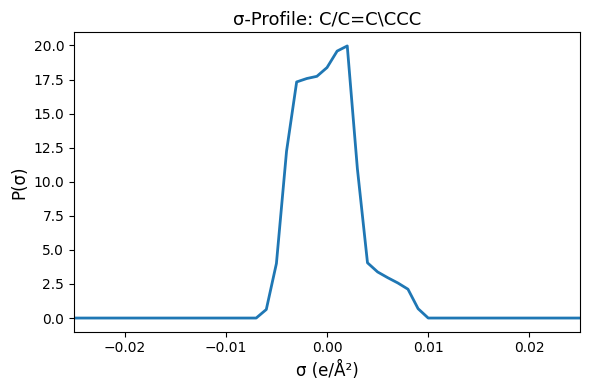

In [3]:
# ==== Input ====
smiles = 'C/C=C\CCC'
# ================

prf, area, volume = sigma_profile_wrapper(smiles)
print(f"Surface Area    : {area:.2f} Å²")
print(f"Molecular Volume: {volume:.2f} Å³")
plot_sigma_prf(smiles, prf)

# Activity Coefficient Prediction

### Choose Model

Select which model to use for predicting activity coefficients:

1. The **Base model** (trained on COSMO-SAC data)
2. The **Fine-tuned model** (refined with experimental data)

Use `"base"` or `"tuned"` as the `model_type` argument below.


In [4]:
gamma_predictor = select_gamma_predictor("tuned")

## Binary System

Define the input for binary mixture prediction:

- `smiles_1`: SMILES of component 1  
- `smiles_2`: SMILES of component 2  
- `temperature`: Temperature in Kelvin 
- `x1_list`: Mole fraction list for component 1 (from 0 to 1)

The mole fraction of component 2 will be automatically set as `1 − x₁`.

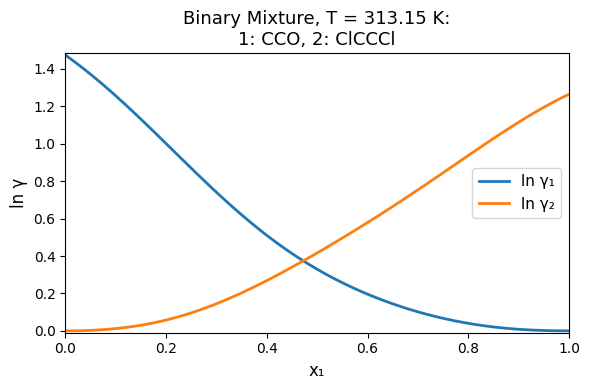

CCO
  Surface Area    : 89.52 Å²
  Molecular Volume: 70.53 Å³
ClCCCl
  Surface Area    : 118.42 Å²
  Molecular Volume: 102.63 Å³


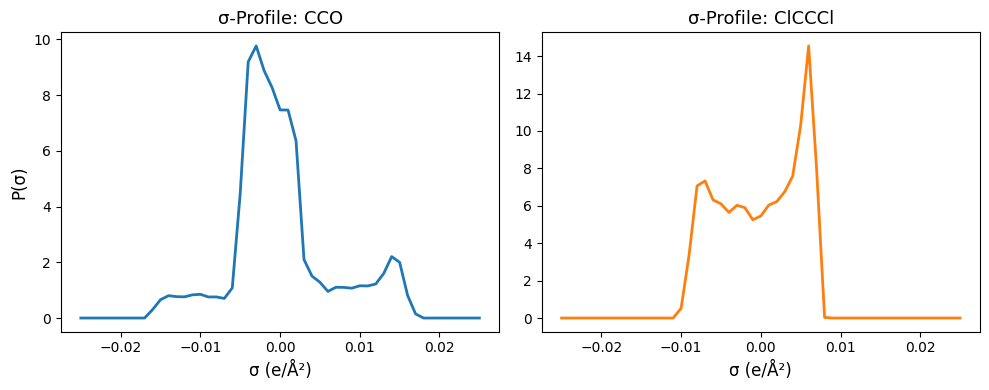

In [5]:
# ==== Input ====
smiles_1 = "CCO"
smiles_2 = "ClCCCl"
temperature = 313.15  # K
x1_list = np.linspace(0.0, 1.0, 101)
# ================

ln_gamma_1_mean, ln_gamma_2_mean, ln_gamma_1_std, ln_gamma_2_std = calc_ln_gamma_binary(
    smiles_1, 
    smiles_2, 
    x1_list.tolist(), 
    temperature,
    gamma_predictors=gamma_predictor,
    get_sigma_profile_fn=sigma_profile_wrapper
)

report_binary_result(smiles_1, smiles_2, x1_list, temperature, ln_gamma_1_mean, ln_gamma_2_mean,
                    get_sigma_profile_fn=sigma_profile_wrapper)


## Multicomponent System

Define the input for a multicomponent mixture:

- `smiles_list`: List of SMILES strings for all *n* components  
- `mole_fraction_list`: Mole fractions for the first *n − 1* components  
  - The last mole fraction is automatically computed as `1 − sum(mole_fraction_list)`  
- `temperature`: Temperature in Kelvin  

The model will predict the activity coefficients (`ln γ`) for each component.


In [ ]:
# ==== Input ====
smiles_list = ['CO', 'CCCc1ccccc1C', 'C/C=C\C', 'O'] # len = n
mole_fraction_list = [0.3, 0.4, 0.1] # len = n - 1
temperature = 298.15  # K
# ================

ln_gamma_mean, ln_gamma_std = calc_ln_gamma(
    smiles_list,
    mole_fraction_list,
    temperature,
    gamma_predictors=gamma_predictor,
    get_sigma_profile_fn=sigma_profile_wrapper
)

df = report_ln_gamma(smiles_list, mole_fraction_list, ln_gamma_mean, temperature)


=== ln γ at T = 298.15 K ===


,SMILES,Mole Fraction,ln γ
0,CO,0.3,0.1790
1,CCCc1ccccc1C,0.4,1.3212
2,C/C=C\C,0.1,0.9149
3,O,0.2,2.3421


array([0.04002088, 0.09908025, 0.05886987, 0.11966505])